In [1]:
#设置回测的开始和结束时间
start_date = '2010-01-01'
end_date   = '2023-03-31'

In [2]:
#加载数据
from firefin.data.gateway import *
data = fetch_data(["open", "close", "volume","return_adj"])

close_price = data["close"].loc[start_date:end_date]
open_price = data["open"].loc[start_date:end_date]
volume = data["volume"].loc[start_date:end_date]


2025-08-22 23:03:24.833 | INFO     | firefin.common.config:<module>:37 - No additional JSON files found in DATA_PATH, load default DATA_MAPS.
D:\PycharmProjects\fire_project\firefin\data\gateway.py:81: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(obj)
D:\PycharmProjects\fire_project\firefin\data\gateway.py:81: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(obj)
2025-08-22 23:03:26.569 | WARNING  | firefin.data.gateway:fetch_data:139 - index is not a valid data name, mock with random data


In [3]:
#计算forward return 1天 5天 10天的收益
from firefin.core.eva_utils import *
# compute forward returns
fr = compute_forward_returns(open_price.shift(-1), [1, 5, 10])

In [4]:
#构造因子(这里仅作为展示，因子的格式是T*N的pd.DataFrame)
def ts_corr(x, y, window=10):
    """
    Wrapper function to estimate rolling correlations.
    :param x, y: pandas DataFrames.
    :param window: the rolling window.
    :return: a pandas DataFrame with the time-series min over the past 'window' days.
    """
    return x.rolling(window).corr(y)

factor = ts_corr(close_price, volume, 20)

In [5]:
# 工业因子的Evaluator 它可以评估一个新的因子的参数，目前这个工具还没有完善
from firefin.evaluation.industry.evaluator import Evaluator
mng =Evaluator(factor, fr)

D:\Anaconda\envs\firefin\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
D:\Anaconda\envs\firefin\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
D:\Anaconda\envs\firefin\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


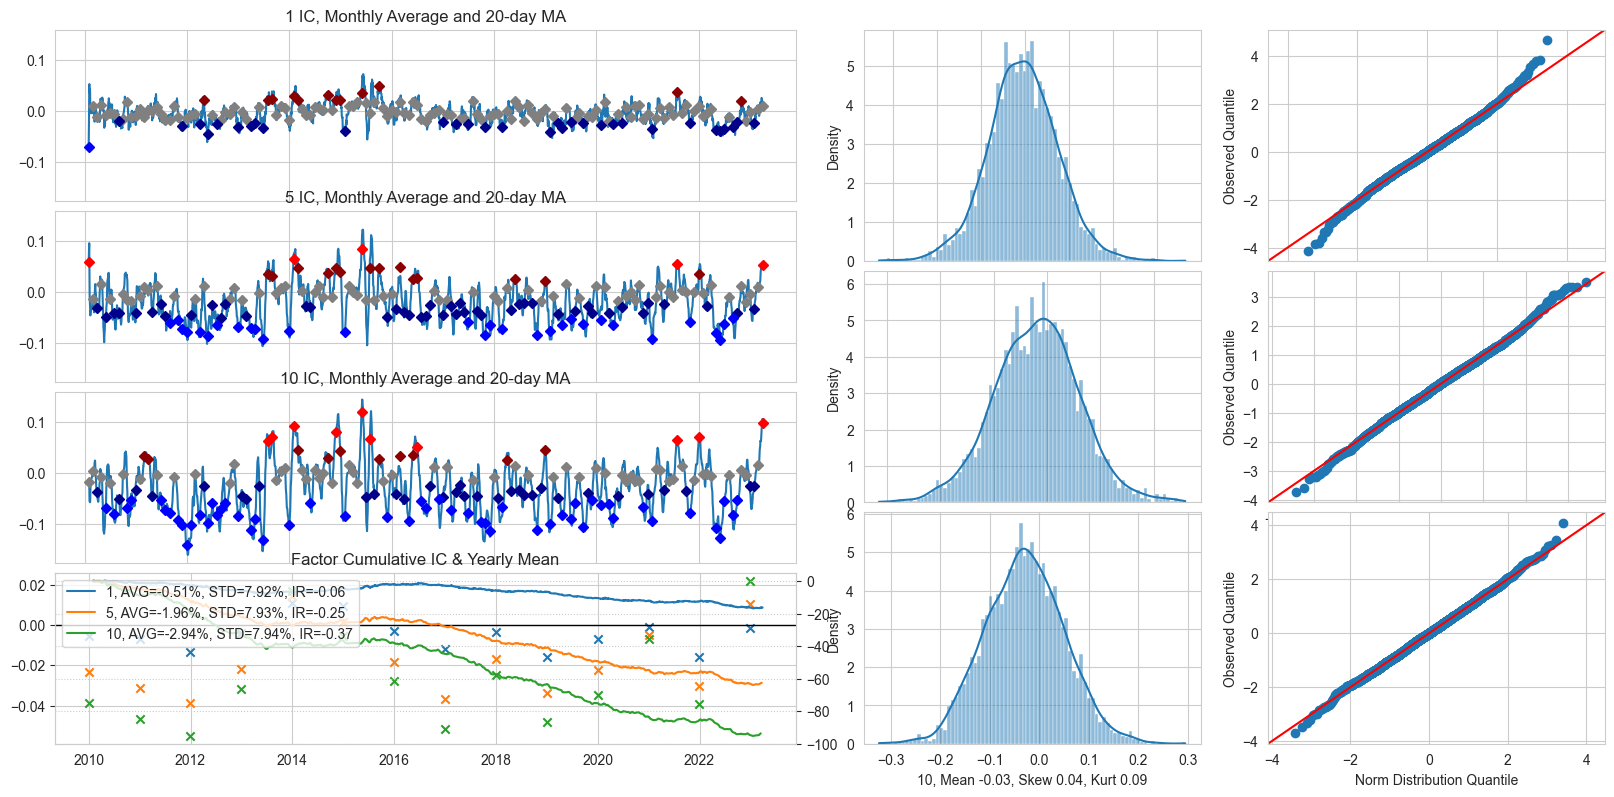

             1         5         10
mean  -0.005125 -0.019612 -0.029382
std    0.079168  0.079279  0.079362
ir    -0.064730 -0.247382 -0.370234
> 0    0.471379  0.408707  0.354141
< 0    0.528621  0.591293  0.645859
> 3%   0.323115  0.259004  0.225220
< -3%  0.375665  0.438772  0.499686
> 5%   0.233031  0.181334  0.157779
< -5%  0.270879  0.352960  0.392409


In [6]:
#获取该因子ic的回测数据
df_ic = mng.get_ic("pearson")

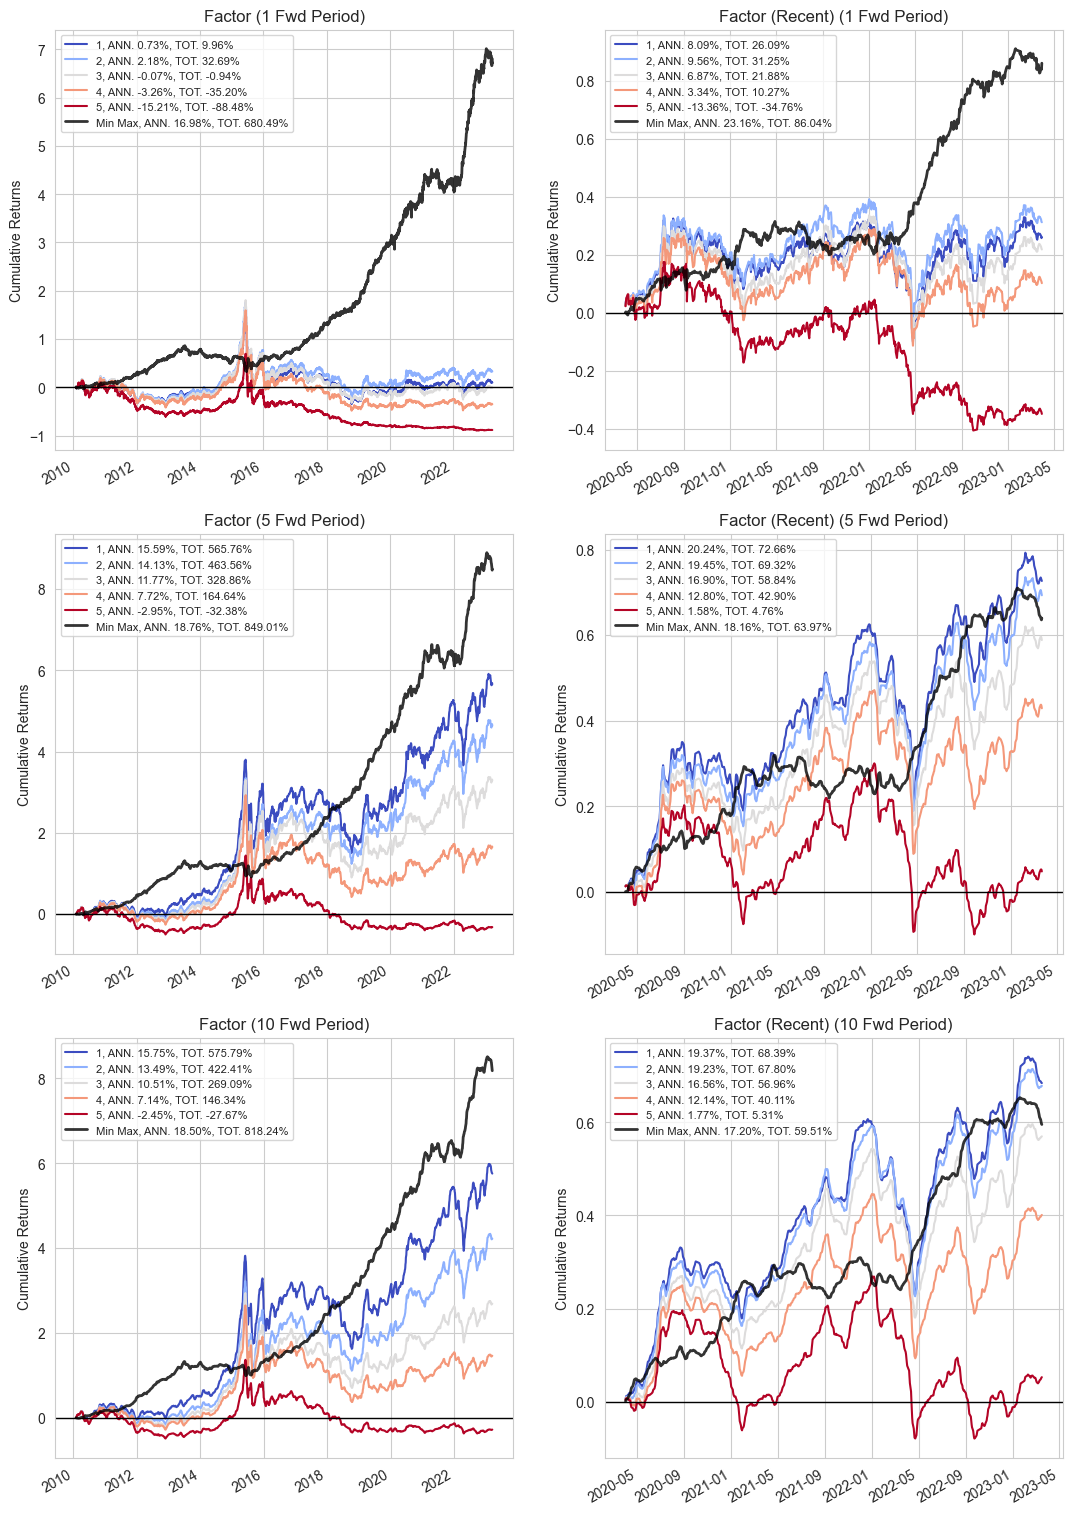

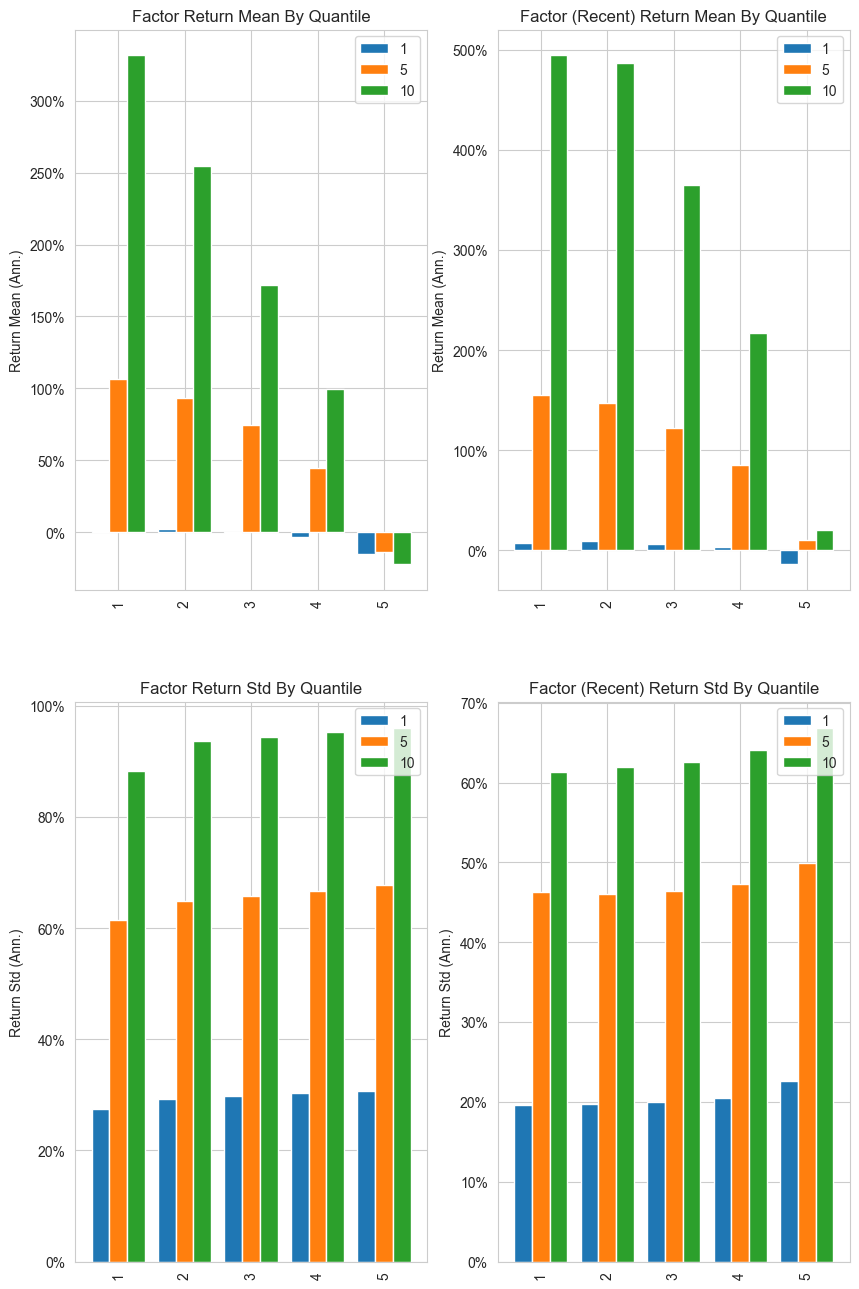

In [7]:
#获取该因子quantile return的回测数据
df_qr = mng.get_quantile_returns(5)

In [8]:
# 第二个因子
def ts_sum(df: pd.DataFrame, window: int = 10) -> pd.DataFrame:
    """Computes the rolling ts_sum for the given window size.

    Args:
        df (pd.DataFrame): tickers in columns, dates in rows.
        window      (int): size of rolling window.

    Returns:
        pd.DataFrame: the ts_sum over the last 'window' days.
    """
    return df.rolling(window).sum()
factor2 = ts_sum(close_price)


D:\Anaconda\envs\firefin\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
D:\Anaconda\envs\firefin\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
D:\Anaconda\envs\firefin\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


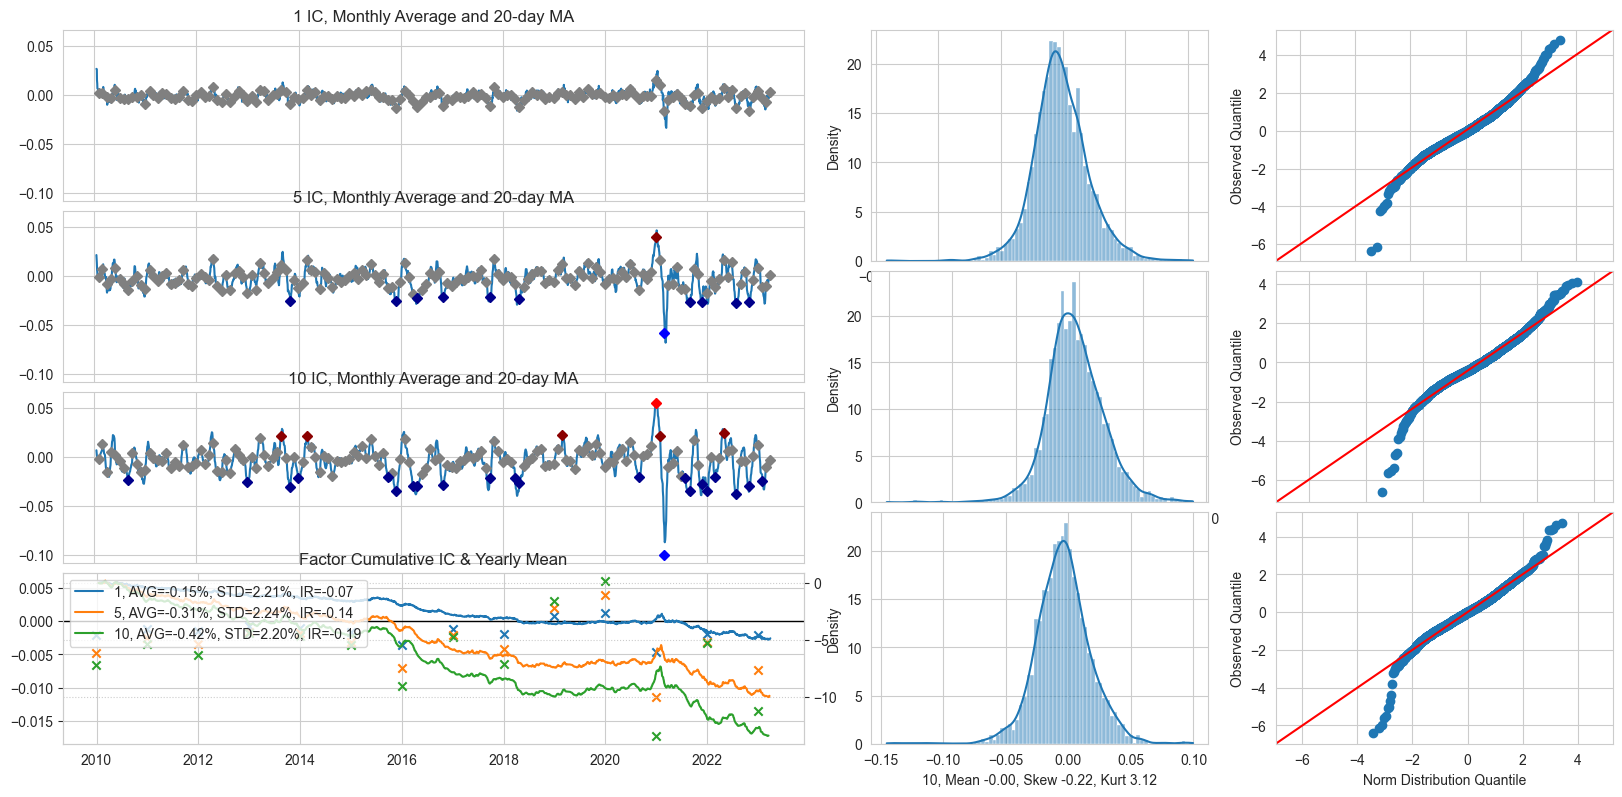

             1         5         10
mean  -0.001511 -0.003093 -0.004193
std    0.022058  0.022426  0.022012
ir    -0.068521 -0.137936 -0.190465
> 0    0.439351  0.411489  0.401188
< 0    0.560649  0.588511  0.598812
> 3%   0.076084  0.066500  0.058787
< -3%  0.068912  0.081174  0.093183
> 5%   0.019333  0.017484  0.009068
< -5%  0.015591  0.017484  0.020638


In [9]:
mng2 =Evaluator(factor2, fr)
df_ic = mng2.get_ic("pearson")

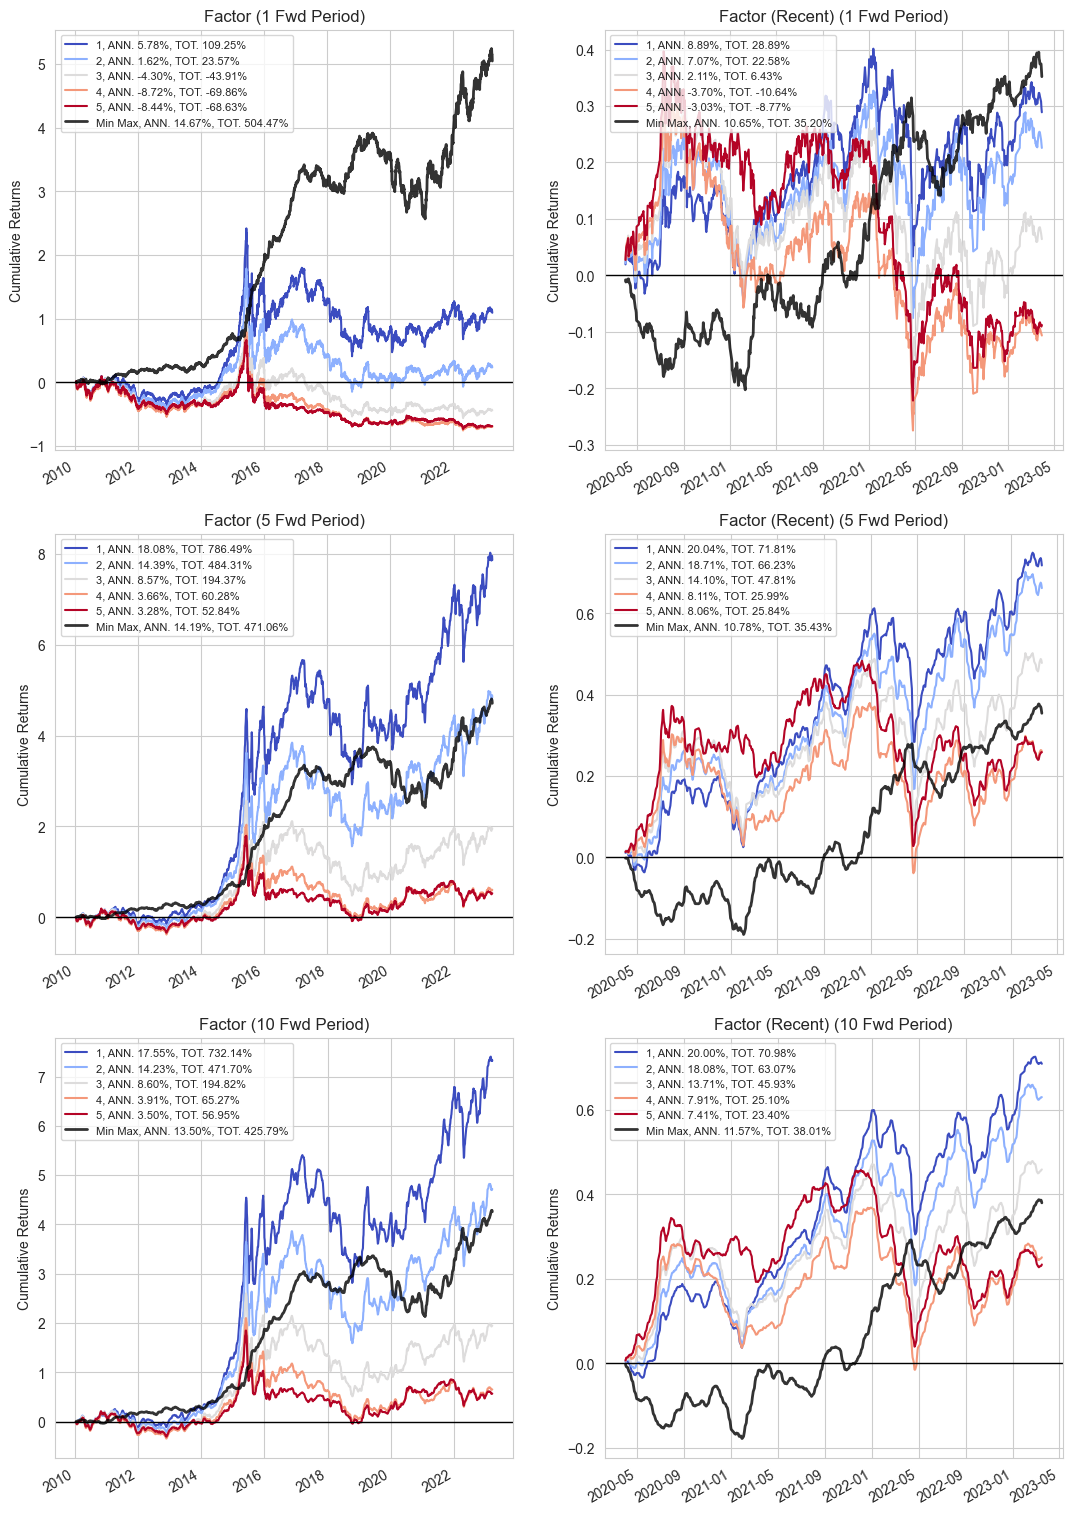

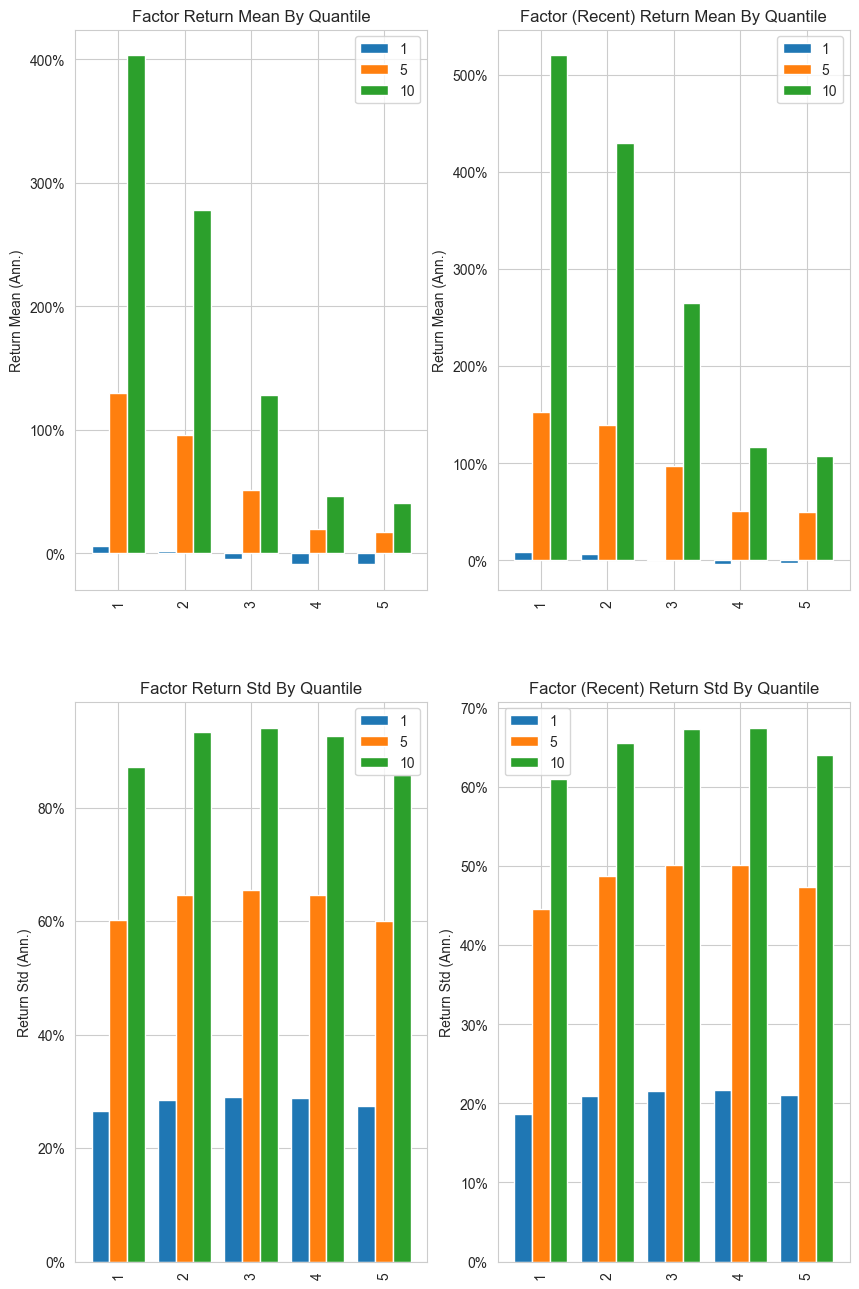

In [10]:
df_qr = mng2.get_quantile_returns(5)

In [11]:
# 第三个因子
def ts_std(df, window=10):
    """
    Wrapper function to estimate rolling standard deviation.
    :param df: a pandas DataFrame.
    :param window: the rolling window.
    :return: a pandas DataFrame with the time-series min over the past 'window' days.
    """
    return (df
            .rolling(window)
            .std())

factor3 = ts_std(volume,window=20)

D:\Anaconda\envs\firefin\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
D:\Anaconda\envs\firefin\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
D:\Anaconda\envs\firefin\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


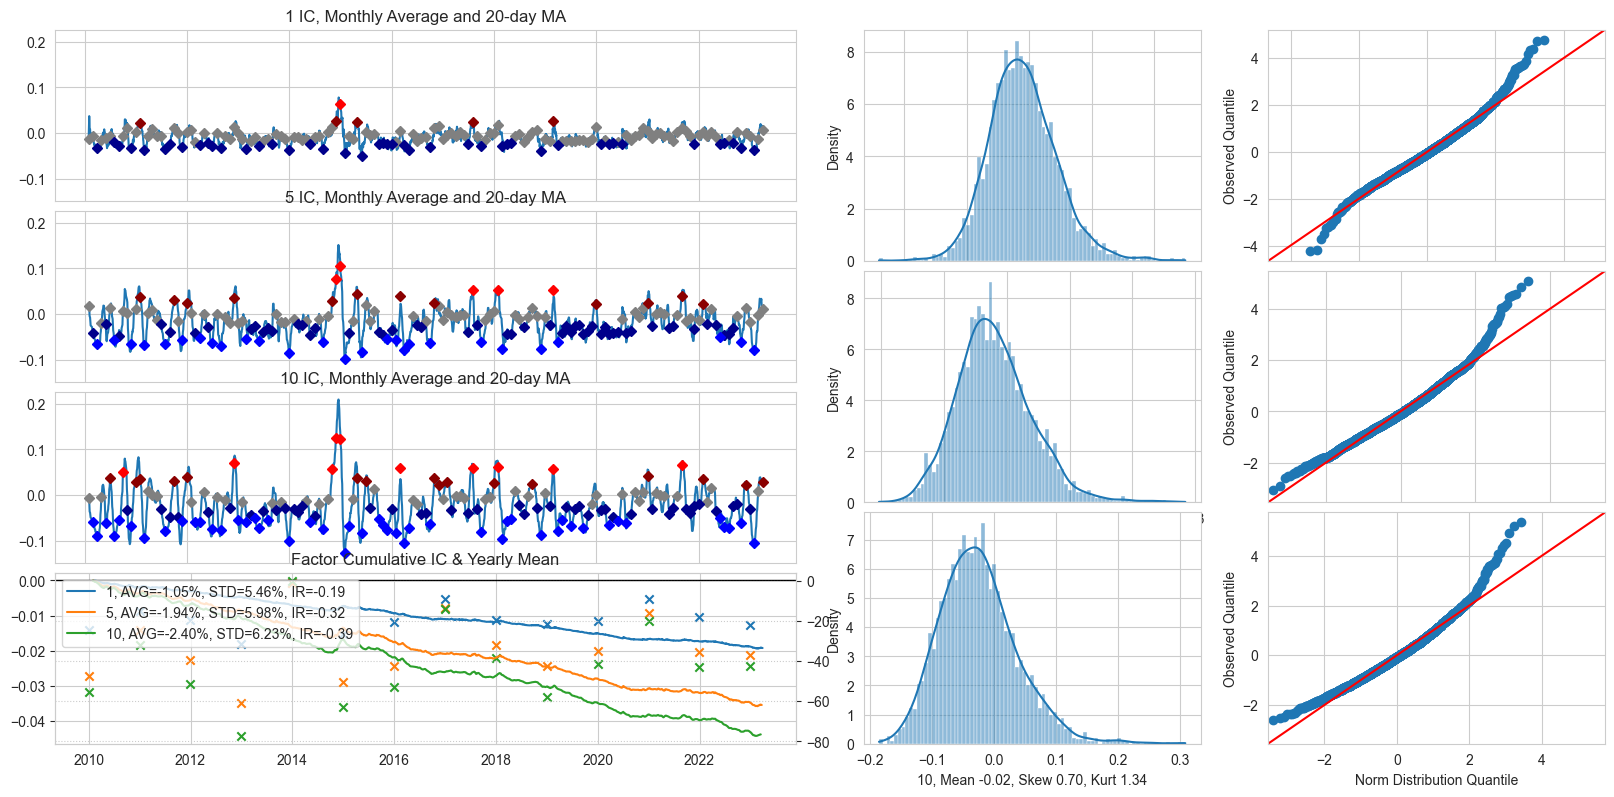

             1         5         10
mean  -0.010469 -0.019366 -0.023996
std    0.054576  0.059815  0.062263
ir    -0.191835 -0.323768 -0.385391
> 0    0.397873  0.339179  0.314617
< 0    0.602127  0.660821  0.685383
> 3%   0.209884  0.186032  0.174090
< -3%  0.373162  0.458503  0.491531
> 5%   0.123553  0.119324  0.114178
< -5%  0.224898  0.315064  0.356023


In [12]:
mng3 =Evaluator(factor3, fr)
df_ic = mng3.get_ic("pearson")

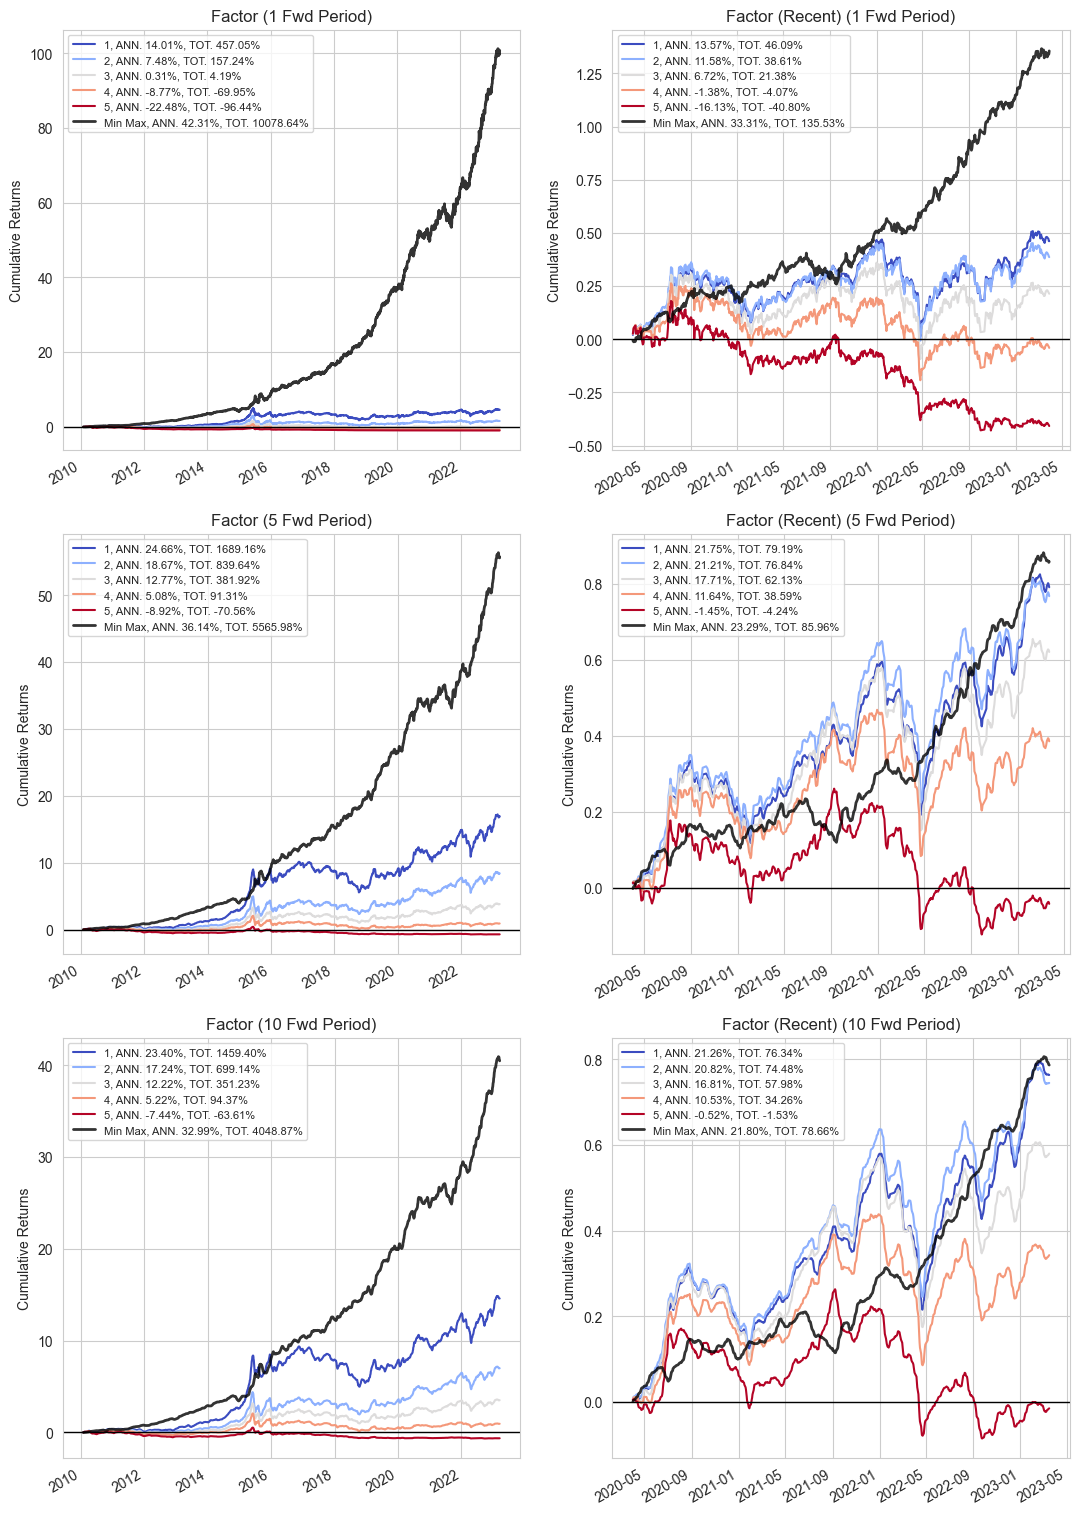

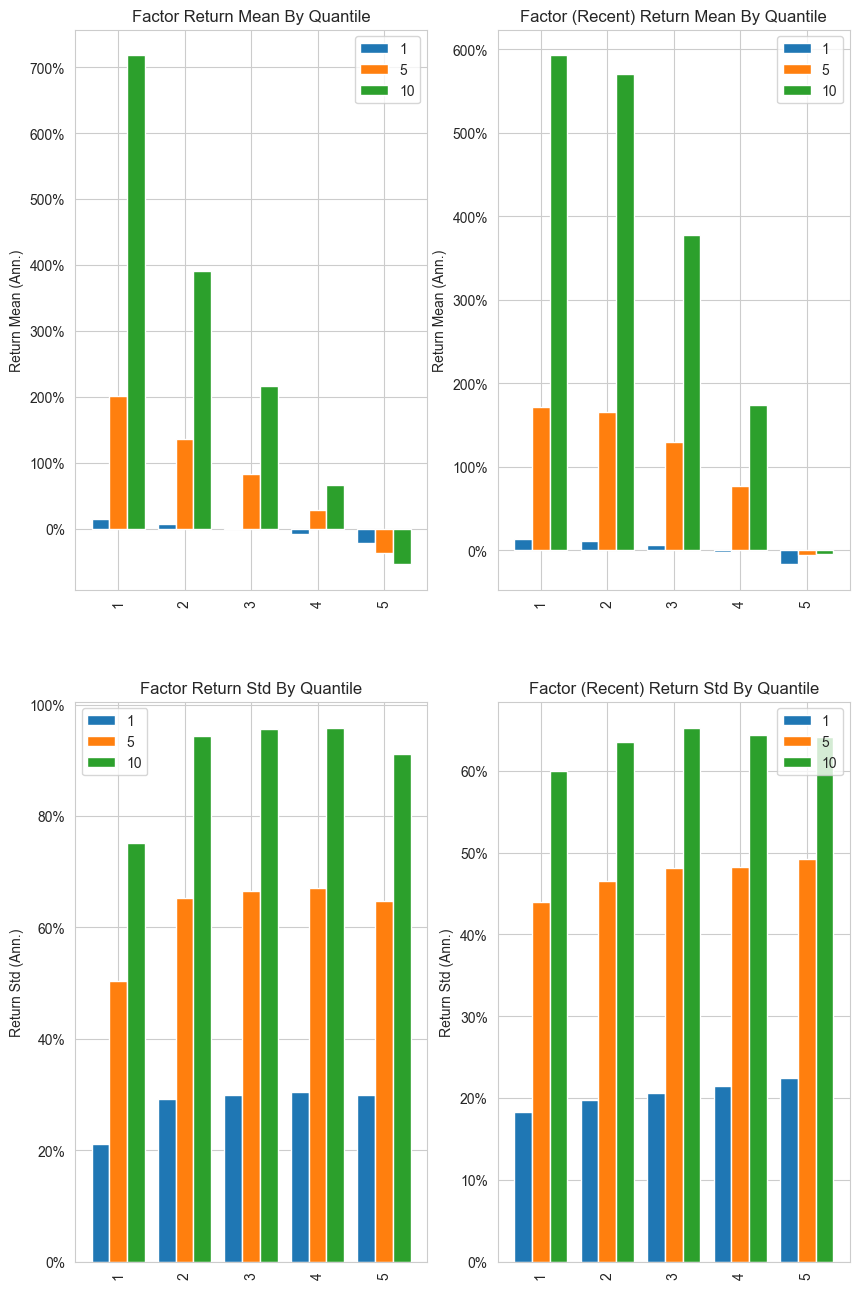

In [13]:
df_qr = mng3.get_quantile_returns(5)

In [14]:
#烂因子
ret_adj = data["return_adj"].loc[start_date:end_date]
ret_5d = ret_adj - ret_adj.shift(4)
factor4 = ret_adj/ts_std(close_price,window=5)

D:\Anaconda\envs\firefin\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
D:\Anaconda\envs\firefin\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
D:\Anaconda\envs\firefin\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


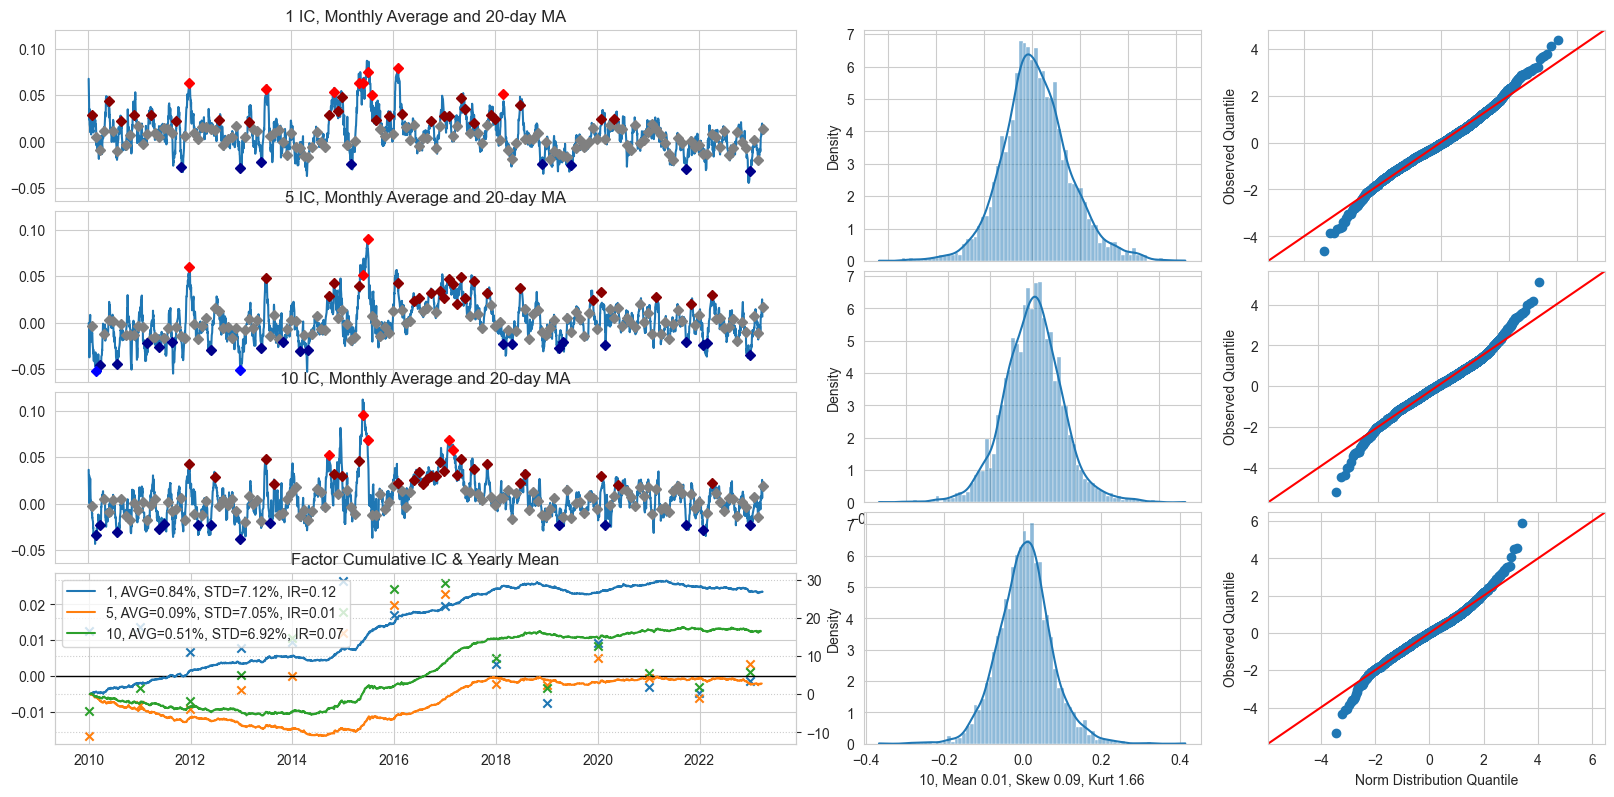

             1         5         10
mean   0.008353  0.000873  0.005138
std    0.071180  0.070457  0.069197
ir     0.117348  0.012389  0.074258
> 0    0.528643  0.510287  0.539182
< 0    0.471357  0.489713  0.460818
> 3%   0.348381  0.317020  0.337808
< -3%  0.273973  0.313903  0.282235
> 5%   0.244085  0.216334  0.222604
< -5%  0.182130  0.212594  0.190759


In [15]:
mng4 =Evaluator(factor4, fr)
df_ic = mng4.get_ic("pearson")

D:\PycharmProjects\fire_project\firefin\core\plot\plots.py:234: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_returns = daily_cum_returns.add(1).pct_change()
D:\PycharmProjects\fire_project\firefin\core\plot\plots.py:234: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_returns = daily_cum_returns.add(1).pct_change()
D:\PycharmProjects\fire_project\firefin\core\plot\plots.py:234: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 

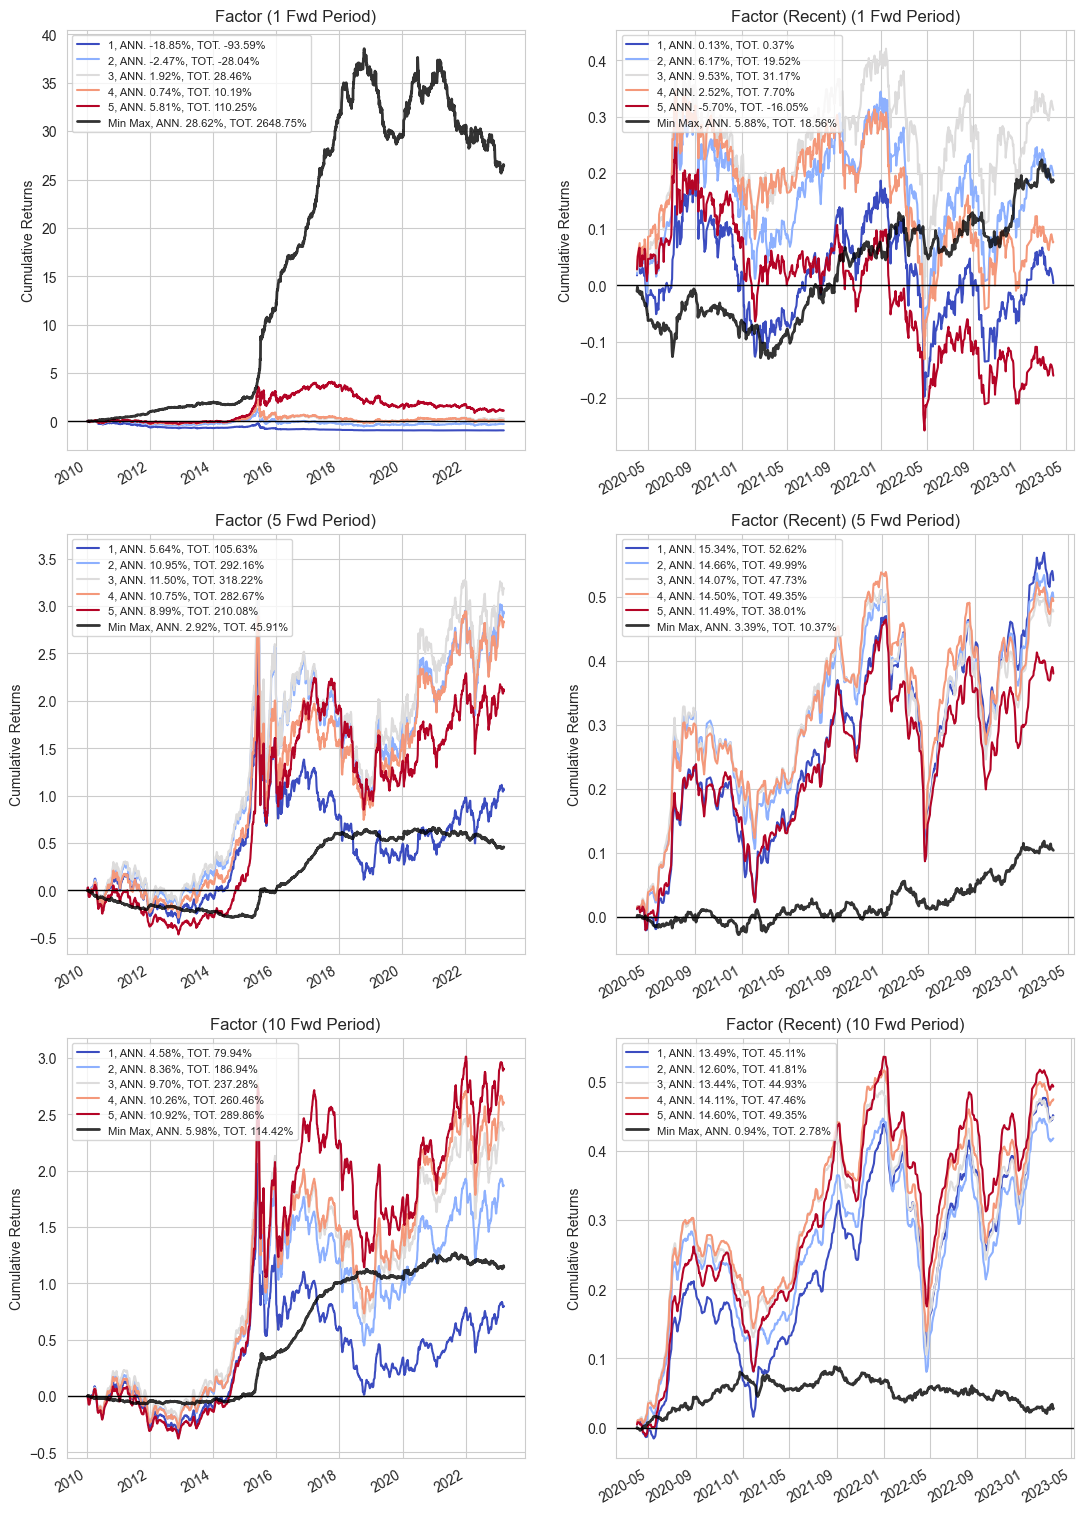

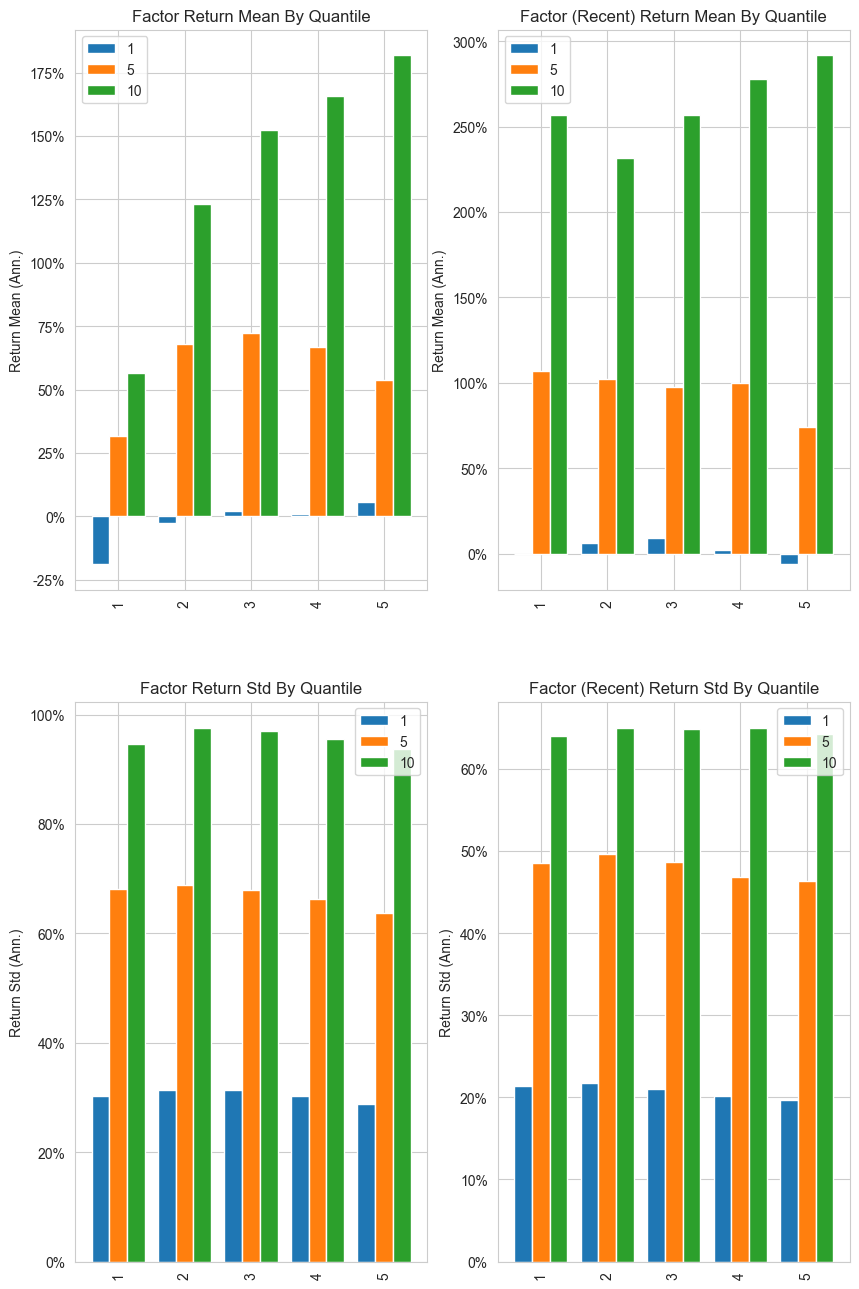

In [16]:
df_qr = mng4.get_quantile_returns(5)